In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import autocast, GradScaler
import timm
import os
import random
from pathlib import Path
from google.colab import drive
from torch.utils.data import DataLoader,random_split
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
drive.mount('/content/drive')

!unzip -q "/content/drive/MyDrive/dataset/AMDNet23_Datasetzip.zip" -d "/content/AMDNet23"


Mounted at /content/drive


In [ ]:
# Configuration
class CFG:
    #DATA PATHS
    DATA_ROOT = "/content/AMDNet23/AMDNet23_Dataset"

    #HYPERPARAMETERS
    IMG_SIZE = 224
    BATCH_SIZE = 16
    SEED = 42
    NUM_WORKERS = 2


    #TRAINING
    EPOCHS_HEAD = 5   # Phase 1: Warming up the fusion layer
    EPOCHS_FULL = 15  # Phase 2: Training the whole system
    LR_HEAD = 1e-3
    LR_FULL = 5e-5    # Lower LR for fine-tuning backbones
    WD = 1e-2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # MODELS = [
    #     "tf_efficientnetv2_s",
    #     "densenet121",
    #     "swin_tiny_patch4_window7_224"
    # ]


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

set_seed(CFG.SEED)

In [ ]:
# Data Augmentation
train_tfms = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

valid_tfms = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

In [ ]:

train_dir = os.path.join(CFG.DATA_ROOT, "train")
test_dir = os.path.join(CFG.DATA_ROOT, "valid")

train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
test_ds = datasets.ImageFolder(test_dir, transform=valid_tfms)

train_size = int(0.8 * len(train_ds))
val_size = len(train_ds) - train_size

train_subset, val_subset = random_split(
    train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_subset, batch_size=CFG.BATCH_SIZE, shuffle=True,num_workers=CFG.NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(val_subset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=CFG.BATCH_SIZE, shuffle=False,num_workers=CFG.NUM_WORKERS, pin_memory=True)

class_names = train_ds.classes
num_classes = len(class_names)
print(f"Classes: {class_names}")

Classes: ['amd', 'cataract', 'diabetes', 'normal']


In [ ]:
class EfficientNetClassifier(nn.Module):
    def __init__(self, model_name, num_classes=10):
        super().__init__()
        print(f"Loading backbone: {model_name}")
        self.backbone = timm.create_model(
            model_name,
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )

        self.num_features = self.backbone.num_features

        self.classifier = nn.Sequential(
            nn.Linear(self.num_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        x = self.classifier(x)
        return x

In [ ]:
def set_backbone_trainable(model, status: bool):
    for p in model.backbone.parameters():
        p.requires_grad = status

In [ ]:
def run_epoch(model, loader, optimizer, scaler, criterion, is_train=True):
    model.train() if is_train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    # Modern device check
    device_type = 'cuda' if 'cuda' in str(CFG.DEVICE) else 'cpu'

    with torch.set_grad_enabled(is_train):
        for x, y in loader:
            x, y = x.to(CFG.DEVICE), y.to(CFG.DEVICE)

            with torch.amp.autocast(device_type=device_type, enabled=(device_type == 'cuda')):
                logits = model(x)
                loss = criterion(logits, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * x.size(0)
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_labels.append(y.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    y_true, y_pred = np.concatenate(all_labels), np.concatenate(all_preds)
    return avg_loss, accuracy_score(y_true, y_pred), f1_score(y_true, y_pred, average='macro')

In [ ]:
def train_feature_fusion():

    model = EfficientNetClassifier(model_name='densenet121', num_classes=10).to(CFG.DEVICE)
    scaler = torch.amp.GradScaler('cuda', enabled=(CFG.DEVICE == 'cuda'))
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    patience = 5
    counter = 0
    best_acc = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # --- Phase 1: Training the Head Only ---
    print("\n[Phase 1] Training Classifier Head (Backbone Frozen)")
    set_backbone_trainable(model, False)

    optimizer = optim.AdamW(model.classifier.parameters(), lr=CFG.LR_HEAD)

    for epoch in range(1, CFG.EPOCHS_HEAD + 1):
        tr_loss, tr_acc, _ = run_epoch(model, train_loader, optimizer, scaler, criterion)
        val_loss, val_acc, val_f1 = run_epoch(model, valid_loader, None, scaler, criterion, is_train=False)

        history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)

        print(f"Ep {epoch}/{CFG.EPOCHS_HEAD} | TrLoss: {tr_loss:.3f} | ValLoss: {val_loss:.3f} | ValAcc: {val_acc:.4f}")

    # --- Phase 2: Full Fine-Tuning ---
    print("\n[Phase 2] Unfreeze all layers for Fine-Tuning")
    set_backbone_trainable(model, True)
    optimizer = optim.AdamW(model.parameters(), lr=CFG.LR_FULL, weight_decay=CFG.WD)

    for epoch in range(1, CFG.EPOCHS_FULL + 1):
        tr_loss, tr_acc, _ = run_epoch(model, train_loader, optimizer, scaler, criterion)
        val_loss, val_acc, val_f1 = run_epoch(model, valid_loader, None, scaler, criterion, is_train=False)

        history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
        history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)
        print(f"Ep {epoch}/{CFG.EPOCHS_FULL} | TrLoss: {tr_loss:.3f} | ValLoss: {val_loss:.3f} | ValAcc: {val_acc:.4f}")

        # Early Stopping Logic
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping triggered at epoch {epoch}.")
                break

    return history

history = train_feature_fusion()

Loading backbone: densenet121


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]


[Phase 1] Training Classifier Head (Backbone Frozen)
Ep 1/5 | TrLoss: 1.098 | ValLoss: 0.866 | ValAcc: 0.8433
Ep 2/5 | TrLoss: 0.924 | ValLoss: 0.868 | ValAcc: 0.8307
Ep 3/5 | TrLoss: 0.888 | ValLoss: 0.792 | ValAcc: 0.8809
Ep 4/5 | TrLoss: 0.867 | ValLoss: 0.823 | ValAcc: 0.8621
Ep 5/5 | TrLoss: 0.847 | ValLoss: 0.813 | ValAcc: 0.8683

[Phase 2] Unfreeze all layers for Fine-Tuning
Ep 1/15 | TrLoss: 0.810 | ValLoss: 0.801 | ValAcc: 0.8746
Ep 2/15 | TrLoss: 0.752 | ValLoss: 0.744 | ValAcc: 0.9154
Ep 3/15 | TrLoss: 0.725 | ValLoss: 0.748 | ValAcc: 0.8966
Ep 4/15 | TrLoss: 0.684 | ValLoss: 0.722 | ValAcc: 0.9216
Ep 5/15 | TrLoss: 0.660 | ValLoss: 0.736 | ValAcc: 0.8934
Ep 6/15 | TrLoss: 0.658 | ValLoss: 0.727 | ValAcc: 0.9154
Ep 7/15 | TrLoss: 0.641 | ValLoss: 0.731 | ValAcc: 0.9091
Ep 8/15 | TrLoss: 0.629 | ValLoss: 0.718 | ValAcc: 0.9122
Ep 9/15 | TrLoss: 0.622 | ValLoss: 0.736 | ValAcc: 0.9091
Early stopping triggered at epoch 9.


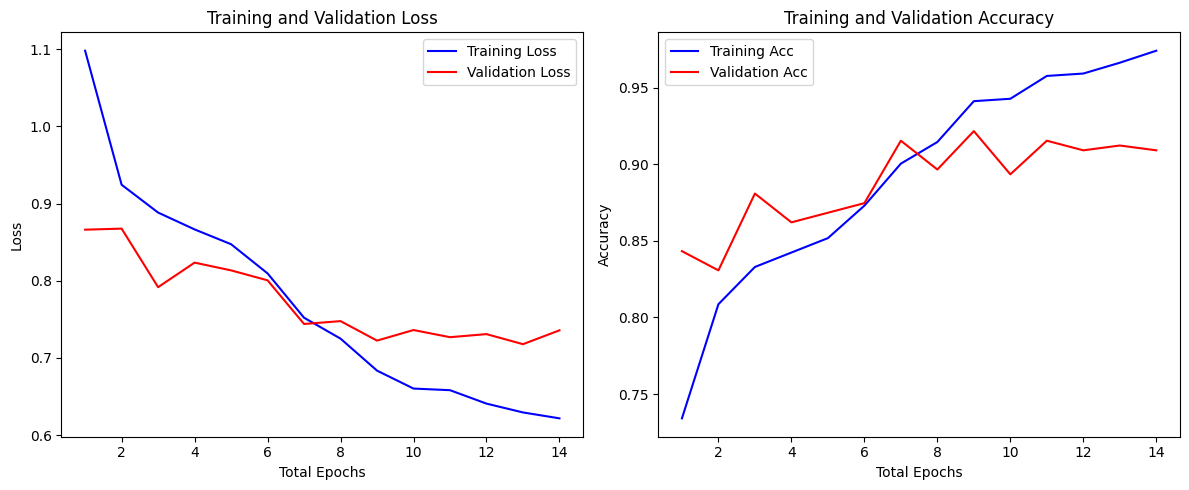

In [ ]:
def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, history['train_loss'], 'b-', label='Training Loss')
    plt.plot(epochs, history['val_loss'], 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Total Epochs')
    plt.ylabel('Loss')
    plt.legend()

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, history['train_acc'], 'b-', label='Training Acc')
    plt.plot(epochs, history['val_acc'], 'r-', label='Validation Acc')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Total Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)


--- FINAL EVALUATION ---
Loading backbone: densenet121
              precision    recall  f1-score   support

         amd       0.90      0.94      0.92       100
    cataract       0.98      0.99      0.99       100
    diabetes       0.90      0.83      0.86       100
      normal       0.91      0.94      0.93       100

    accuracy                           0.93       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.93      0.92       400



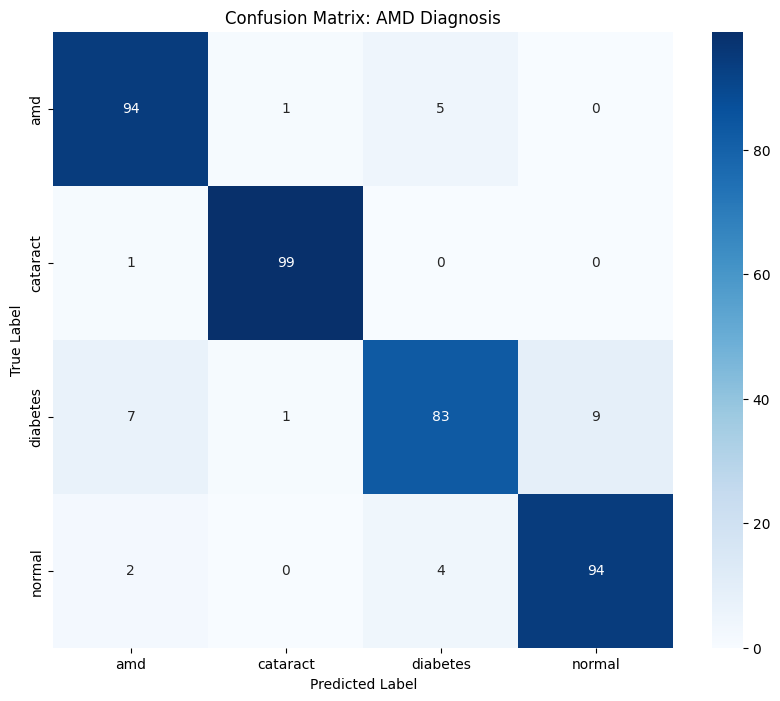

In [ ]:
# 8. Evaluation Function
def test_model(model_path):
    print("\n--- FINAL EVALUATION ---")

    model = EfficientNetClassifier(model_name='densenet121', num_classes=10).to(CFG.DEVICE)
    model.load_state_dict(torch.load(model_path))
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(CFG.DEVICE)
            logits = model(x)
            all_preds.append(logits.argmax(1).cpu().numpy())
            all_labels.append(y.numpy())
    y_true, y_pred = np.concatenate(all_labels), np.concatenate(all_preds)

    print(classification_report(y_true, y_pred, target_names=class_names))


    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names,
                yticklabels=class_names)

    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix: AMD Diagnosis')
    plt.show()

test_model("best_model.pth")